# 03 – Baseline model: NYC Citi Bike

**Worked on by:** Andreas Schellekens (shared protocol for the model notebooks, baseline choice, evaluation, deployable pipeline); Mihai Constantin (re-run and check of the results on a second machine, text corrections after a review)

> **GenAI disclosure:** the first version of this notebook was drafted with the help of Claude Code (AI assistant), based on `01c_eda_hypothesis.ipynb` and `02_data_preparation.ipynb`. All steps were reviewed by the team; we must be able to explain every cell ourselves.

## 1. Goal and setup

A **quick first model** for daily demand: not the best one, but a working model that the deployment (API, frontend, retraining pipeline) can be built around while later notebooks look for better models. It also sets the bar that every later model has to beat, and this notebook fixes the **protocol** that all Citi Bike model notebooks follow (section 3), so their numbers can be compared in the comparison notebook.

Imports, paths and the chart style of the Citi Bike notebooks. The split dates and file names come from `models/citibike_daily_dataset.json`, written by `02_data_preparation.ipynb`, so they are defined in one place only.

In [1]:
import os
os.environ.setdefault("LOKY_MAX_CPU_COUNT", "4")

import json
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pandas.tseries.holiday import USFederalHolidayCalendar
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import make_scorer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 200)

INK_PRIMARY, INK_SECONDARY, INK_MUTED = "#0b0b0b", "#52514e", "#898781"
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white", "axes.edgecolor": "#c3c2b7",
    "axes.grid": True, "grid.color": "#e1e0d9", "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.labelcolor": INK_SECONDARY, "xtick.color": INK_MUTED, "ytick.color": INK_MUTED,
    "text.color": INK_PRIMARY, "axes.titlesize": 12, "axes.titleweight": "bold",
})
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"

NOTEBOOK = "03_model_baseline"
MODEL_DIR = Path("models")
MODEL_PATH = MODEL_DIR / "citibike_baseline.joblib"
METRICS_PATH = MODEL_DIR / "metrics.csv"
with open(MODEL_DIR / "citibike_daily_dataset.json", encoding="utf-8") as file:
    DATASET = json.load(file)


def load(split):
    return pd.read_csv(DATASET["files"][split], index_col="date", parse_dates=["date"])


train, validation, test = load("train"), load("validation"), load("test")
for name, frame in [("train", train), ("validation", validation), ("test", test)]:
    print(f"{name:>10}: {frame.index.min():%Y-%m-%d} .. {frame.index.max():%Y-%m-%d}, {len(frame):,} days, "
          f"mean {frame.total.mean():,.0f} trips per day")

     train: 2014-07-01 .. 2023-12-31, 3,471 days, mean 55,680 trips per day
validation: 2024-01-01 .. 2024-12-31, 366 days, mean 120,467 trips per day
      test: 2025-01-01 .. 2026-08-30, 607 days, mean 124,264 trips per day


## 2. What the model predicts

The target is the number of trips per day, `total`. 02 (section 6) showed that every validation and test day lies in a busier period than any training day, and recommended predicting `demand_ratio` = trips / `level_12m` instead: how busy the day is compared with an average day of the 12 months that ended two months earlier. We predict the **logarithm** of that ratio, for two reasons:

- weather and calendar effects are **multiplicative**: rain costs about the same *share* of the trips on a quiet and on a busy day (01b section 2). On the log scale they become additive, which is what a linear model needs;
- the ratio is skewed (a storm day can be 0.05, a busy day about 1.8); the logarithm makes it more symmetric.

The prediction in trips is then `exp(predicted log ratio) x level_12m`.

## 3. The protocol for all Citi Bike model notebooks

Fixed here, before any model is compared, and to be followed by every later model notebook (as the mushroom model notebooks share one protocol):

1. **Fit target:** `log(demand_ratio)`. Every saved pipeline takes the input columns of section 8 and returns the predicted log ratio; trips = `exp(prediction) x level_12m`.
2. **Days without trips** (9 storm days in train, 1 in test): the logarithm of 0 does not exist, so they are left out of **fitting**. They stay in the **evaluation**: the MAE counts them with their full error.
3. **Metrics**, always in trips, computed by the helper `evaluate` below and stored in `models/metrics.csv`:
   - `mae`: mean absolute error in trips per day (all days);
   - `rmse`: root mean squared error (all days; punishes large misses more);
   - `mape`: mean absolute percentage error on the days with trips, comparable with 01c;
   - `median_ape` and `within_20pct` (share of days with an error of at most 20%);
   - `bias_pct`: the mean signed percentage error. Positive means the model predicts too many trips. This shows the trend problem of 02 (section 6).
4. **Choices** (model type, hyperparameters) are made with **yearly folds inside the training period**: fit on all training days before a year, predict that year, as in 02 section 7. The predicted years are 2016-2019 and 2022-2023. 2020 and 2021 stay in the training data of later folds, but are not predicted: no model can predict a pandemic, and with errors of 60-90% (02 section 7) one fold would decide every choice. For scikit-learn searches the folds are passed as `cv=yearly_folds(...)` with `scoring=mape_scorer`. That scorer computes the MAPE **in trips** from the log ratio: trips = ratio x level, so the percentage error is `exp(predicted log ratio - actual log ratio) - 1` and the level cancels out. (A first version scored the MAE on the log scale; in 05a it chose a model that was worse in trips, because an error on the log scale is not symmetric in trips.)
5. **The validation year 2024** checks those choices and is used to choose between models; it is never fitted on.
6. **The test period** (1 January 2025 - 30 August 2026) is evaluated **once per model**, after all choices, and never changes a choice.
7. The final model is fitted on the whole training period (no refit on train + validation, as with the mushrooms: the deployed model is the validated one).

In [2]:
CV_YEARS = [2016, 2017, 2018, 2019, 2022, 2023]


def yearly_folds(index, years=CV_YEARS):
    """(fit positions, predict positions) per year: fit on every day before the year, predict the year."""
    positions = np.arange(len(index))
    return [(positions[index.year < year], positions[index.year == year]) for year in years]


def trips_mape(actual_log_ratio, predicted_log_ratio):
    """MAPE in trips, computed from the log ratio (the level cancels out)."""
    return np.mean(np.abs(np.expm1(predicted_log_ratio - actual_log_ratio))) * 100


mape_scorer = make_scorer(trips_mape, greater_is_better=False)


def evaluate(name, split, actual, predicted):
    """Metrics in trips for one model on one set; MAPE-type metrics only on days with trips."""
    error = predicted - actual
    has_trips = actual > 0
    percentage = error[has_trips] / actual[has_trips] * 100
    return {
        "model": name, "notebook": NOTEBOOK, "split": split, "days": len(actual),
        "mae": error.abs().mean(), "rmse": np.sqrt((error ** 2).mean()),
        "mape": percentage.abs().mean(), "median_ape": percentage.abs().median(),
        "within_20pct": (percentage.abs() <= 20).mean() * 100, "bias_pct": percentage.mean(),
    }


fit_days = train[train.total > 0]
print(f"{len(fit_days):,} training days with trips; fold sizes (fit days, predicted days):")
print([(year, len(fit), len(predict)) for year, (fit, predict) in zip(CV_YEARS, yearly_folds(fit_days.index))])

3,462 training days with trips; fold sizes (fit days, predicted days):
[(2016, 549, 362), (2017, 911, 361), (2018, 1272, 365), (2019, 1637, 365), (2022, 2732, 365), (2023, 3097, 365)]


## 4. Which baseline?

Three candidates, from simple to less simple:

1. **Seasonal naive:** the predicted ratio is the median `demand_ratio` of the training days with the same month and weekday, times the level. It learns no weather, so it is the floor: a model that does not beat it has learned nothing from the weather (the "calendar model" of H4 in 01c, in its simplest form).
2. **Linear regression on the total:** the weather model of 01c, now on `log(demand_ratio)`: weekday, month, federal holiday, Christmas week, maximum temperature and its square, precipitation class and snow on the ground. 02 section 7 used it as a measuring instrument; here it becomes a real, deployable model in a scikit-learn pipeline (one-hot encoding for the categories, `PolynomialFeatures` for the temperature curve).
3. **Linear regression per user type, added up:** H1 (01c) showed that casual riders react more strongly to rain. Two models of the same form, one for members (`member / member_level_12m`) and one for casual riders, and the prediction is the sum. If H1 matters for prediction, this should be better than model 2.

Why a linear model as the baseline? It is fast, has nothing to tune, its coefficients can be read as percentages (section 7), and 01b/01c already showed that this form explains most of the variation. **Paths not taken:** a single decision tree (cannot extrapolate temperatures or levels outside the training range and needs pruning, which is tuning) and boosting or forests (candidates for the tuned models).

In [3]:
FEATURES = ["weekday", "month", "holiday", "christmas_week", "tmax_c", "precipitation", "snow_on_ground"]


def linear_pipeline():
    prepare = ColumnTransformer([
        ("categories", OneHotEncoder(drop="first", handle_unknown="ignore"), ["weekday", "month", "precipitation"]),
        ("temperature", PolynomialFeatures(degree=2, include_bias=False), ["tmax_c"]),
        ("flags", "passthrough", ["holiday", "christmas_week", "snow_on_ground"]),
    ])
    return Pipeline([("prepare", prepare), ("model", LinearRegression())])


def predict_naive(fit, days):
    ratio = fit[fit.total > 0].groupby(["month", "weekday"]).demand_ratio.median().rename("ratio")
    return days.join(ratio, on=["month", "weekday"]).ratio * days.level_12m


def predict_linear(fit, days):
    fit = fit[fit.total > 0]
    model = linear_pipeline().fit(fit[FEATURES], np.log(fit.demand_ratio))
    return np.exp(model.predict(days[FEATURES])) * days.level_12m


def predict_per_user_type(fit, days):
    prediction = 0
    for user_type in ["member", "casual"]:
        part = fit[fit[user_type] > 0]
        model = linear_pipeline().fit(part[FEATURES], np.log(part[user_type] / part[f"{user_type}_level_12m"]))
        prediction = prediction + np.exp(model.predict(days[FEATURES])) * days[f"{user_type}_level_12m"]
    return prediction


CANDIDATES = {"seasonal naive": predict_naive, "linear, total": predict_linear,
              "linear, per user type": predict_per_user_type}

Every candidate is scored on the yearly folds of section 3 (fitted on the training days before the year, all days of the year predicted) and, fitted on the whole training period, on the validation year 2024.

In [4]:
fold_rows = []
for year in CV_YEARS:
    fit, days = train[train.index.year < year], train[train.index.year == year]
    for name, predict in CANDIDATES.items():
        fold_rows.append(evaluate(name, str(year), days.total, predict(fit, days)))
folds = pd.DataFrame(fold_rows)

summary = folds.groupby("model", sort=False)[["mae", "mape", "within_20pct", "bias_pct"]].mean().add_prefix("folds_")
validation_rows = [evaluate(name, "validation", validation.total, predict(train, validation))
                   for name, predict in CANDIDATES.items()]
summary = summary.join(pd.DataFrame(validation_rows).set_index("model")[["mae", "mape", "within_20pct", "bias_pct"]]
                       .add_prefix("validation_"))
print("MAPE per predicted year:")
print(folds.pivot(index="model", columns="split", values="mape").loc[list(CANDIDATES)].round(1).to_string())
summary.round(1)

MAPE per predicted year:
split                  2016  2017  2018  2019  2022  2023
model                                                    
seasonal naive         30.3  35.8  42.1  27.0  32.1  22.5
linear, total          18.8  19.0  19.2  17.0  16.3  14.3
linear, per user type  19.7  18.3  18.8  16.4  16.3  14.5


,folds_mae,folds_mape,folds_within_20pct,folds_bias_pct,validation_mae,validation_mape,validation_within_20pct,validation_bias_pct
model,,,,,,,,
seasonal naive,11333.3,31.6,60.0,15.2,17755.7,22.2,71.9,5.2
"linear, total",8270.6,17.4,71.3,2.2,12787.6,12.4,82.2,-4.2
"linear, per user type",8344.1,17.3,71.3,1.3,12176.8,12.2,80.3,-5.0


**Interpretation**

- **Weather almost halves the error.** Both linear models are far better than the seasonal naive model: a mean MAPE over the folds of 17.4% against 31.6%, and 12.4% against 22.2% on the validation year. This is H4 of 01c again, now with a model that can be deployed.
- **Per user type or total: practically equal.** Per user type is a little better on the folds (17.3% against 17.4% MAPE) and on the validation MAPE and MAE (12.2% against 12.4%; 12,177 against 12,787 trips), but worse on the share of days within 20% (80.3% against 82.2%) and in two of the six fold years (2016, 2023). Why so little gain, although H1 holds? Members make about 82% of the trips, so the total behaves mostly like the members; the stronger rain reaction of casual riders is a small part of the total, and the total model already averages it in.
- The validation year is predicted **better** than the fold years (12.4% against 17.4%): later folds have more training years, and the fold errors fall over time as well (14.3% in 2023).

**Decision:** the baseline is the **linear regression on the total**. It is as good as the per-user-type version with half the parts (one model and one level instead of two), which matters for the deployment. Per-user-type models stay an option for the tuned models.

## 5. Final fit, validation and test

The chosen model is fitted once on all training days with trips, then evaluated on the validation year and **once** on the test period. The seasonal naive model is evaluated on the same days as a reference. The validation numbers are the ones later notebooks may use to compare models; the test numbers are only reported.

In [5]:
baseline = linear_pipeline().fit(fit_days[FEATURES], np.log(fit_days.demand_ratio))


def predict_trips(model, days):
    return pd.Series(np.exp(model.predict(days[FEATURES])) * days.level_12m, index=days.index)


predictions = {split: predict_trips(baseline, days) for split, days in [("validation", validation), ("test", test)]}
results = []
for split, days in [("validation", validation), ("test", test)]:
    results.append(evaluate("seasonal naive", split, days.total, predict_naive(train, days)))
    results.append(evaluate("linear regression (baseline)", split, days.total, predictions[split]))
pd.DataFrame(results).drop(columns="notebook").set_index(["model", "split"]).round(1)

,,days,mae,rmse,mape,median_ape,within_20pct,bias_pct
model,split,,,,,,,
seasonal naive,validation,366,17755.7,24079.1,22.2,10.9,71.9,5.2
linear regression (baseline),validation,366,12787.6,16670.3,12.4,9.7,82.2,-4.2
seasonal naive,test,607,24128.1,32296.4,38.0,14.7,61.9,31.6
linear regression (baseline),test,607,17205.6,22336.1,17.4,11.9,73.6,7.8


**Interpretation**

- **Validation 2024:** MAPE 12.4%, an average miss of 12,787 trips on an average day of 120,467 trips, 82% of the days within 20%. The seasonal naive model: 22.2%.
- **Test 2025-2026 (reported once):** MAPE 17.4%, MAE 17,206 trips, 73.6% of the days within 20%, and a **bias of +7.8%**: the model predicts too many trips on average. That is clearly worse than on validation. Section 6 shows that the extra error is not random: it drifts with time.
- Over all hold-out days of 01c (2024 to August 2026, 972 days with trips) the baseline has a MAPE of 15.5%, against 16.2% for the weather model with a linear trend in 01c. The level helps, but less than hoped, because a new problem appears in 2025-2026 (section 6).
- The naive model breaks down on the test period (38.0%, bias +31.6%), a first sign of the same drift.

## 6. Where does the baseline go wrong?

The error analysis uses the **validation** year (the test period is only reported). First the whole year: the actual trips per day and the prediction, and below it the mean signed error per month for the validation **and** test periods, to see whether the model drifts over time.

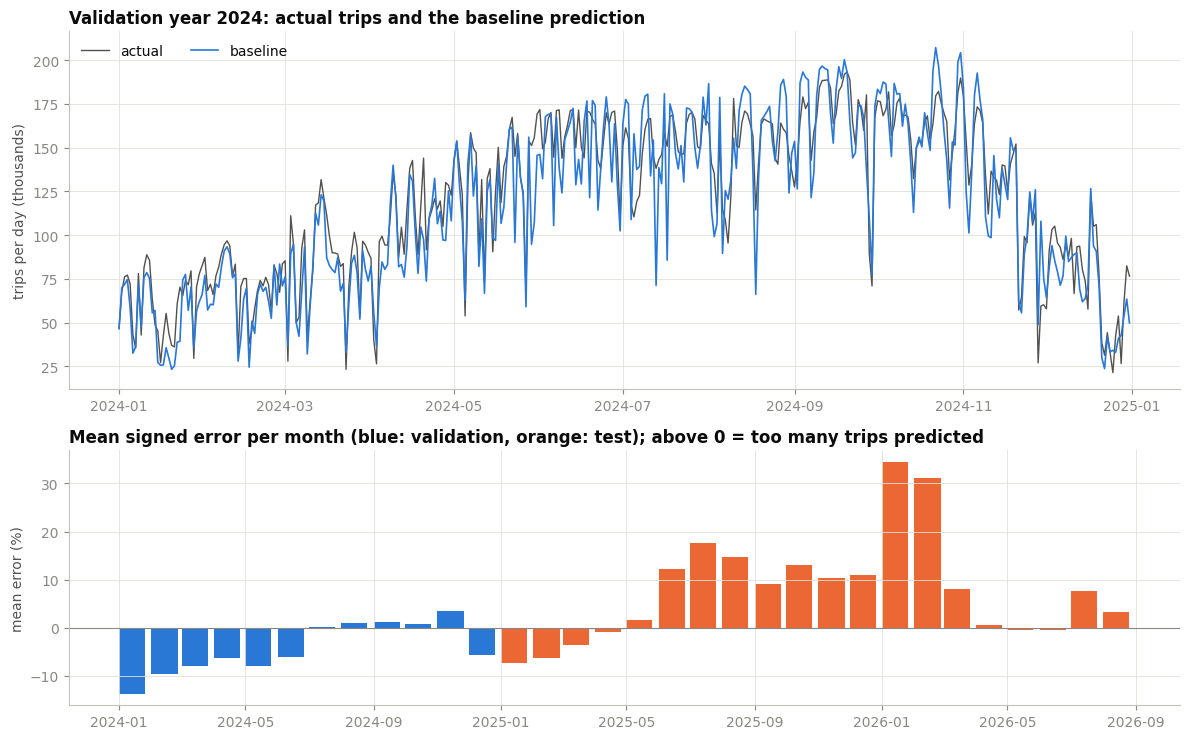

date,2024-01-01,2024-02-01,2024-03-01,2024-04-01,2024-05-01,2024-06-01,2024-07-01,2024-08-01,2024-09-01,2024-10-01,2024-11-01,2024-12-01,2025-01-01,2025-02-01,2025-03-01,...,2025-06-01,2025-07-01,2025-08-01,2025-09-01,2025-10-01,2025-11-01,2025-12-01,2026-01-01,2026-02-01,2026-03-01,2026-04-01,2026-05-01,2026-06-01,2026-07-01,2026-08-01
bias_pct,-13.7,-9.7,-8.0,-6.2,-7.8,-6.1,0.2,0.9,1.3,0.9,3.5,-5.6,-7.3,-6.2,-3.5,...,12.2,17.7,14.7,9.2,13.1,10.3,11.0,34.6,31.1,8.1,0.6,-0.3,-0.5,7.6,3.3


In [6]:
fig, (top, bottom) = plt.subplots(2, 1, figsize=(12, 7.5), height_ratios=[1.4, 1])
top.plot(validation.index, validation.total / 1e3, color=INK_SECONDARY, linewidth=1, label="actual")
top.plot(validation.index, predictions["validation"] / 1e3, color=BLUE, linewidth=1.2, label="baseline")
top.set_ylabel("trips per day (thousands)")
top.set_title("Validation year 2024: actual trips and the baseline prediction", loc="left")
top.legend(loc="upper left", frameon=False, ncol=2)

monthly_bias = pd.concat([
    ((predictions[split] - days.total) / days.total * 100)[days.total > 0].resample("MS").mean()
    for split, days in [("validation", validation), ("test", test)]])
colours = [BLUE if month.year == 2024 else ORANGE for month in monthly_bias.index]
bottom.bar(monthly_bias.index, monthly_bias.values, width=25, align="edge", color=colours)
bottom.axhline(0, color=INK_MUTED, linewidth=0.8)
bottom.set_ylabel("mean error (%)")
bottom.set_title("Mean signed error per month (blue: validation, orange: test); above 0 = too many trips predicted",
                 loc="left")
fig.tight_layout()
plt.show()
monthly_bias.round(1).to_frame("bias_pct").T

**Interpretation:** the errors per month are not random; there are three patterns.

- **Growth year 2024: too low in the first half** (-14% in January to -6% in June), about right from July. The level is an average of months that are on average seven and a half months old; in a year of fast growth the actual demand is further above that level than the model learned.
- **2025: too high from June** (+9% to +18% per month). Growth stopped in 2025 (January-August 2026 has as many trips as January-August 2025, 01a section 6), so the level caught up with demand. But in almost every training year the system grew, and the model learned that a day is usually about 15% above the level (median ratio per training year 1.06 to 1.31, only 2020 below 1). It still expects growth that no longer comes. This is the trend problem of 02 section 6, now measured.
- **January and February 2026: +34% and +31%.** The coldest and snowiest weeks of the hold-out period: snow on the ground on 13 days in January and 22 days in February 2026, with a mean depth of 115 mm in February. The model only knows "snow on the ground: yes or no" and the temperature, so a deep, lasting snow cover costs more trips than it expects.

Ideas for better models: a feature for the **recent growth** (for example the last published months against the same months a year earlier), **snow depth** as a number instead of a flag, or giving recent training years more weight.

The ten largest misses of the validation year, with the weather and the calendar of the day:

In [7]:
misses = validation.assign(predicted=predictions["validation"].round(0),
                           error_pct=(predictions["validation"] - validation.total) / validation.total * 100)
misses.reindex(misses.error_pct.abs().sort_values(ascending=False).index).head(10)[
    ["total", "predicted", "error_pct", "tmax_c", "precipitation_mm", "precipitation", "snow_on_ground", "holiday",
     "christmas_week", "weekday"]].round(1)

,total,predicted,error_pct,tmax_c,precipitation_mm,precipitation,snow_on_ground,holiday,christmas_week,weekday
date,,,,,,,,,,
2024-11-29,59514,107989.0,81.5,8.3,0.0,dry,0,0,0,4
2024-11-28,26983,48846.0,81.0,9.4,21.8,heavy,0,1,0,3
2024-12-28,26579,42734.0,60.8,12.2,14.2,heavy,0,0,1,5
2024-12-25,21436,34175.0,59.4,1.7,0.0,dry,1,1,0,2
2024-07-13,138185,71297.0,-48.4,30.6,52.3,very heavy,0,0,0,5
2024-01-23,70288,39333.0,-44.0,4.4,1.3,light,1,0,0,1
2024-07-17,150769,85713.0,-43.1,32.2,37.1,very heavy,0,0,0,2
2024-07-05,110422,157958.0,43.0,32.2,2.5,light,0,0,0,4
2024-08-18,114381,66160.0,-42.2,27.2,58.2,very heavy,0,0,0,6


**Interpretation**

- **Thanksgiving week:** on Thanksgiving (28 November, also heavy rain) the model predicts 81% too many trips, and on the day after (Friday 29 November, not a federal holiday) also 81.5% too many. The model has one holiday effect for all holidays (-32%, section 7), while 01b (section 3.1) found -68% for members on Thanksgiving; and the day after Thanksgiving is an unofficial day off that it does not know at all.
- **Christmas:** Christmas Day +59% and 28 December (Christmas week plus heavy rain) +61%: Christmas costs members far more than an average holiday (-73% in 01b).
- **Summer storms:** on three summer days with very heavy rain (13 and 17 July, 18 August) there were 42-48% more trips than predicted. If a thunderstorm falls in a short burst in the evening or at night, the daily total in millimetres overstates its effect; daily data cannot tell when the rain fell.
- **Old snow:** on 23 January and 14 February 2024 there was 30 and 50 mm of snow on the ground but no new snow, and 42-44% more trips than predicted: the yes/no flag treats a few centimetres of old snow like a fresh, deep cover.

Candidate features for the tuned models: separate effects for the big holidays (Thanksgiving and the day after, Christmas, New Year's Day) and snow depth as a number.

## 7. What did the model learn?

On the log scale every coefficient is a multiplicative effect: `exp(coefficient) - 1` is the change in trips in percent compared with the reference (Monday, January, a dry day without snow, not a holiday). The temperature effect is a curve, so we show it at a few temperatures compared with 20 degrees.

In [8]:
names = baseline.named_steps["prepare"].get_feature_names_out()
coefficients = pd.Series(baseline.named_steps["model"].coef_, index=names)
effects = (np.exp(coefficients) - 1) * 100
selected = [name for name in names if "precipitation" in name or "weekday" in name or name.startswith("flags")]
print("Effect in % (against Monday / a dry day / no holiday):")
print(effects[selected].round(1).to_string())

b1, b2 = coefficients["temperature__tmax_c"], coefficients["temperature__tmax_c^2"]
temperatures = np.array([-5, 0, 5, 10, 15, 25, 30, 35])
curve = (np.exp(b1 * (temperatures - 20) + b2 * (temperatures ** 2 - 400)) - 1) * 100
print("\nTemperature effect against 20 degrees:")
print(pd.Series(curve.round(1), index=[f"{t} C" for t in temperatures]).to_string())
print(f"peak of the curve at {-b1 / (2 * b2):.1f} degrees")

Effect in % (against Monday / a dry day / no holiday):
categories__weekday_1                    5.4
categories__weekday_2                    5.6
categories__weekday_3                    3.9
categories__weekday_4                    2.1
categories__weekday_5                  -11.4
categories__weekday_6                  -18.8
categories__precipitation_heavy        -37.7
categories__precipitation_light         -9.3
categories__precipitation_moderate     -24.4
categories__precipitation_very heavy   -52.4
flags__holiday                         -32.1
flags__christmas_week                  -35.3
flags__snow_on_ground                  -34.1

Temperature effect against 20 degrees:
-5 C   -69.1
0 C    -57.4
5 C    -43.7
10 C   -28.8
15 C   -13.8
25 C    11.1
30 C    18.1
35 C    20.3
peak of the curve at 34.6 degrees


**Interpretation:** the model learned what the EDA found, which makes us trust it.

- **Rain:** light -9.3%, moderate -24.4%, heavy -37.7%, very heavy -52.4% against a dry day, almost the same as in 01b (-9.7%, -23.3%, -37.9%, -54.1%), although this model uses another target (the ratio instead of trips with an effect for every month of every year) and fewer years.
- **Temperature:** at 0 degrees -57% against 20 degrees (01b: -56%), at 30 degrees +18%. The curve is a parabola with its top at 34.6 degrees, so above 30 degrees it is almost flat (01b: top at about 32 degrees).
- **Weekdays** against Monday: Tuesday to Thursday +4 to +6%, Saturday -11%, Sunday -19%. The weekend drop is smaller than for members alone in 01b (-22% and -28%), because casual riders ride more at weekends; the total mixes both groups.
- **Holiday** -32% and **Christmas week** -35%: one effect for all holidays, the average of members (fewer trips) and casual riders (more trips).
- **Snow on the ground** -34%, more than in 01b (-24%). Probably because 01b had a separate level for every month of every year, which absorbed part of the difference between snowy and mild winters; here only the month of the year is known, so the snow flag takes over that part.

## 8. Saving the model for deployment

The API will receive a **date** and a **weather forecast** (maximum temperature, precipitation in mm, snow depth in mm). It must turn those into the input columns of the model, exactly as 02 did, and multiply the prediction by the level of that date. The function `features_for_day` below is that recipe, written once so the API can copy it:

- `weekday`, `month`, `holiday` (US federal), `christmas_week` from the date;
- `precipitation` class from the millimetres (02 section 4) and `snow_on_ground` from the snow depth;
- `level_12m` from `Data/citibike_monthly.csv`: the mean trips per day over the months *m-13* to *m-2*.

We check the recipe on **every** test day: from only the date, the measured weather and the monthly file, it must reproduce the test rows and the predictions of section 5. Then the pipeline (preprocessing + linear regression, fitted on train only) is saved with `joblib`, with a JSON file that describes its input and output.

In [9]:
monthly = pd.read_csv(DATASET["files"]["monthly"], index_col="month", parse_dates=["month"])
HOLIDAYS = USFederalHolidayCalendar().holidays("2013-01-01", "2035-12-31")


def features_for_day(date, tmax_c, precipitation_mm, snow_depth_mm, monthly=monthly):
    """The model input for one day, from the date, a weather forecast and the monthly trip totals."""
    date = pd.Timestamp(date)
    month_day = date.strftime("%m-%d")
    holiday = int(date in HOLIDAYS)
    precipitation = pd.cut([precipitation_mm], [-0.1, 0, 2.5, 10, 25, np.inf],
                           labels=["dry", "light", "moderate", "heavy", "very heavy"])[0]
    window = monthly.loc[(date.to_period("M") - 13).to_timestamp():(date.to_period("M") - 2).to_timestamp()]
    assert len(window) == 12, "the monthly file does not cover the 12 months m-13 .. m-2"
    return pd.DataFrame([{
        "weekday": date.dayofweek, "month": date.month, "holiday": holiday,
        "christmas_week": int((month_day >= "12-24" or month_day <= "01-01") and not holiday),
        "tmax_c": tmax_c, "precipitation": str(precipitation), "snow_on_ground": int(snow_depth_mm > 0),
        "level_12m": window.total.sum() / window.days.sum(),
    }], index=[date])


rebuilt = pd.concat([features_for_day(day, row.tmax_c, row.precipitation_mm, row.snow_depth_mm)
                     for day, row in test.iterrows()])
pd.testing.assert_frame_equal(rebuilt[FEATURES], test[FEATURES], check_dtype=False, check_names=False)
assert np.allclose(rebuilt.level_12m, test.level_12m)
assert np.allclose(predict_trips(baseline, rebuilt), predictions["test"])
print(f"recipe reproduces all {len(test)} test days and their predictions")

joblib.dump(baseline, MODEL_PATH)
description = {
    "model": "citibike_baseline", "notebook": NOTEBOOK, "estimator": "LinearRegression in a Pipeline",
    "input_columns": FEATURES,
    "output": "log(demand_ratio); predicted trips = exp(output) * level_12m",
    "level_12m": DATASET["level_definition"],
    "trained_on": DATASET["splits"]["train"],
    "validation": {key: round(value, 2) for key, value in results[1].items() if key in ("mae", "mape", "bias_pct")},
}
with open(MODEL_DIR / "citibike_baseline.json", "w", encoding="utf-8") as file:
    json.dump(description, file, indent=2)
print(f"saved {MODEL_PATH} ({MODEL_PATH.stat().st_size / 1024:.0f} KB) and citibike_baseline.json")

recipe reproduces all 607 test days and their predictions
saved models\citibike_baseline.joblib (4 KB) and citibike_baseline.json


## 9. Storing the metrics

As with the mushrooms, every model notebook adds its rows to one shared file, `models/metrics.csv` (here in `NYCCitiBikeSystemData/models/`), which the comparison notebook will read. A re-run replaces the notebook's own rows instead of adding duplicates.

In [10]:
new_rows = pd.DataFrame(results)
if METRICS_PATH.exists():
    metrics = pd.read_csv(METRICS_PATH)
    metrics = pd.concat([metrics[metrics.notebook != NOTEBOOK], new_rows], ignore_index=True)
else:
    metrics = new_rows
metrics.to_csv(METRICS_PATH, index=False)
metrics.round(1)

,model,notebook,split,days,mae,rmse,mape,median_ape,within_20pct,bias_pct
0,PyCaret blend gbr + rf + lightgbm,04_model_automl,validation,366,9657.7,12700.3,9.5,6.3,88.5,-3.1
1,PyCaret blend gbr + rf + lightgbm,04_model_automl,test,607,13806.2,17529.1,14.6,9.8,80.9,8.6
2,gradient boosting (05a),05a_model_gradient_boosting,validation,366,9499.5,12207.3,9.6,6.4,86.1,-3.1
3,gradient boosting (05a),05a_model_gradient_boosting,test,607,14577.8,18235.1,15.1,10.4,80.0,8.8
4,Huber regression (05b),05b_model_huber,validation,366,11645.3,15293.6,10.8,8.7,88.3,-2.7
5,Huber regression (05b),05b_model_huber,test,607,15837.4,20535.3,15.7,11.2,77.9,9.4
6,ensemble 05a + 05b (05c),05c_model_ensemble,validation,366,9712.1,12667.1,9.3,6.8,90.2,-3.1
7,ensemble 05a + 05b (05c),05c_model_ensemble,test,607,14363.4,18112.8,14.4,10.2,81.4,8.8
8,seasonal naive,03_model_baseline,validation,366,17755.7,24079.1,22.2,10.9,71.9,5.2
9,linear regression (baseline),03_model_baseline,validation,366,12787.6,16670.3,12.4,9.7,82.2,-4.2


## 10. Conclusion and next steps

- **Baseline:** linear regression on `log(demand_ratio)` with weekday, month, holiday, Christmas week, maximum temperature (curve), precipitation class and snow on the ground. Validation MAPE 12.4% (MAE 12,787 trips per day), test MAPE 17.4% (MAE 17,206, bias +7.8%). The seasonal naive model without weather: 22.2% and 38.0%.
- **Protocol** for all Citi Bike model notebooks (section 3): target `log(demand_ratio)`, days without trips out of fitting but in the evaluation, metrics in trips via `evaluate`, choices on yearly folds inside train (2016-2019, 2022-2023) and on the validation year, the test period once, metrics in `models/metrics.csv`.
- **Per user type** (H1) gives practically the same accuracy as one model on the total; not used for the baseline.
- **Where the errors come from:** the level drifts (too low in the growth year 2024, too high once growth stopped in 2025), extreme winters (January-February 2026), the big holidays, and rain that falls at night. Day-to-day weather is handled well.
- **Deployable:** `models/citibike_baseline.joblib` (4 KB) with `citibike_baseline.json`. The API needs the date, a forecast (maximum temperature, precipitation, snow depth) and `Data/citibike_monthly.csv`; `features_for_day` (section 8) is the recipe, checked on all 607 test days.

**Next steps**

- `04_model_automl.ipynb`: PyCaret regression on the same target, features and yearly folds (PyCaret accepts a custom fold generator).
- `05_model_*.ipynb`: tuned non-linear models (for example gradient boosting), with the candidate features of section 6 (big holidays, snow depth, recent growth) tested on the yearly folds and the validation year.